In [2]:
import pymcel as pc 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np 
from mpl_toolkits.mplot3d import Axes3D
import plotly.io as pio

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='erfa')

### 1. Configuración e inicialización 

In [4]:
#fecha un poco antes del encuentro para tener una referencia de la órbita de Apophis 
fecha_ref = '2029-01-01 00:00:00'

#Extraer de pymcel (están en m^3/s^2) 
mu_sol = pc.constantes.mu_sun 
mu_tierra = pc.constantes.mu_earth 
mu_luna = pc.constantes.mu_moon 
mu_jupiter = pc.constantes.mu_jupiter 

def estado(id_obj):
    # pymcel consulta Horizons y ya debería devolver (m) y (m/s)
    _, _, X = pc.consulta_horizons(id=id_obj, location='@sun', epochs=fecha_ref)
    
    # Imprimimos para verificar en consola (una sola vez)
    # Para la Tierra, la norma debería ser aprox 1.5e11
    dist = np.linalg.norm(X[:3])    
    return X[:3], X[3:] # Retorna posición (m) y velocidad (m/s)


#obtenemos el estado de los objetos
r_sol = np.zeros(3) #el Sol está en el origen

r_tierra, v_tierra = estado('399') #estado de la Tierra
r_luna, v_luna = estado('301') #estado de la Luna
r_jupiter, v_jupiter = estado('599') #estado de Júpiter
r_apophis, v_apophis = estado('99942') #estado de Apophis

### 2. Aplicar la integración numérica de $N$-cuerpos

Para resolver las ecuaciones de movimiento del sistema se implementará el algoritmo de integración numérica **Leapfrog**.

* Funcionamiento matemático

La estructura utilizada sigue el esquema de tres sub-pasos por cada intervalo de tiepo $\Delta t$:

1. **Medio paso de posición:** Se actualiza la posición del cuerpo hasta la mitad del intervalo temporal usando la velocidad actual: 

$$r( t +\frac{1}{2} \Delta t) = r(t) + v(t) \frac{1}{2} \Delta t$$

2. **Paso de velocidad**: Se calcula la aceleración gravitatoria $a$ en la nueva posición media y se actualiza la velocidad completa para todo el intervalo: 

$$v(t+ \Delta t) = v(t) + a(t + \frac{1}{2} \Delta t) \Delta t$$

3. **Medio paso de posición**: Se completa la actualización de la posición usando la nueva velocidad: 

$$r(t + \Delta t) = r( t +\frac{1}{2} \Delta t) + v(t + \Delta t) \frac{1}{2} \Delta t$$

In [5]:
#El tiempo son 5 meses desde enero hasta mayo
delta_t = 30 #segundos
dias_simulacion = 150 #días
N_steps = int((dias_simulacion*86400)/delta_t) #Número de pasos para 150 días

pos_tierra = np.zeros((N_steps, 3))
pos_apophis = np.zeros((N_steps, 3))
vel_apophis_hist = np.zeros((N_steps, 3)) 
vel_tierra_hist = np.zeros((N_steps, 3))  
vel_luna_hist = np.zeros((N_steps, 3))
vel_jupiter_hist = np.zeros((N_steps, 3))
distancias = np.zeros(N_steps)

#Método de integración Leapfrog para la simulación de la órbita 
for i in range(N_steps):
    #Distancia relativa Apophis - Tierra
    pos_tierra[i] = r_tierra
    pos_apophis[i] = r_apophis
    vel_apophis_hist[i] = v_apophis
    vel_tierra_hist[i] = v_tierra
    vel_luna_hist[i] = v_luna
    vel_jupiter_hist[i] = v_jupiter
    distancias[i] = np.linalg.norm(r_apophis - r_tierra)

    # DRIFT (Medio paso de posición)
    r_ap_half = r_apophis + v_apophis * (delta_t*0.5)
    r_tr_half = r_tierra + v_tierra * (delta_t*0.5)
    r_ln_half = r_luna + v_luna * (delta_t*0.5)
    r_ju_half = r_jupiter + v_jupiter * (delta_t*0.5)

    #Función aceleración 
    def aceleracion(p_obj, p_atr, mu_atr):
        r_vec = p_obj - p_atr
        r_mag = np.linalg.norm(r_vec)
        return -mu_atr * r_vec / r_mag**3
    
    #KICK (Paso completo de velocidad)
    a_ap = aceleracion(r_ap_half, r_sol, mu_sol) + aceleracion(r_ap_half, r_tr_half, mu_tierra) \
        + aceleracion(r_ap_half, r_ln_half, mu_luna) + aceleracion(r_ap_half, r_ju_half, mu_jupiter)
    
    a_tr = aceleracion(r_tr_half, r_sol, mu_sol) + aceleracion(r_tr_half, r_ju_half, mu_jupiter)
    a_ln = aceleracion(r_ln_half, r_sol, mu_sol) + aceleracion(r_ln_half, r_tr_half, mu_tierra)
    a_ju = aceleracion(r_ju_half, r_sol, mu_sol)

    #Actualizamos velocidades
    v_apophis += a_ap * delta_t
    v_tierra += a_tr * delta_t
    v_luna += a_ln * delta_t
    v_jupiter += a_ju * delta_t

    #DRIFT (Medio paso de posición)
    r_apophis = r_ap_half + v_apophis * (delta_t*0.5)
    r_tierra = r_tr_half + v_tierra * (delta_t*0.5)
    r_luna = r_ln_half + v_luna * (delta_t*0.5)
    r_jupiter = r_ju_half + v_jupiter * (delta_t*0.5)

### 3. Cálculo de resultados

In [6]:
idx_min = np.argmin(distancias)
print(f"Distancia mínima: {distancias[idx_min]:,.2f} m")
print(f"Altitud: {distancias[idx_min] - 6371:,.2f} m")
print(f"Día del perigeo: {idx_min * delta_t / 86400:.2f} días desde el 1 de Enero")

Distancia mínima: 180,102,775.12 m
Altitud: 180,096,404.12 m
Día del perigeo: 103.18 días desde el 1 de Enero


### 4. Gráfica 


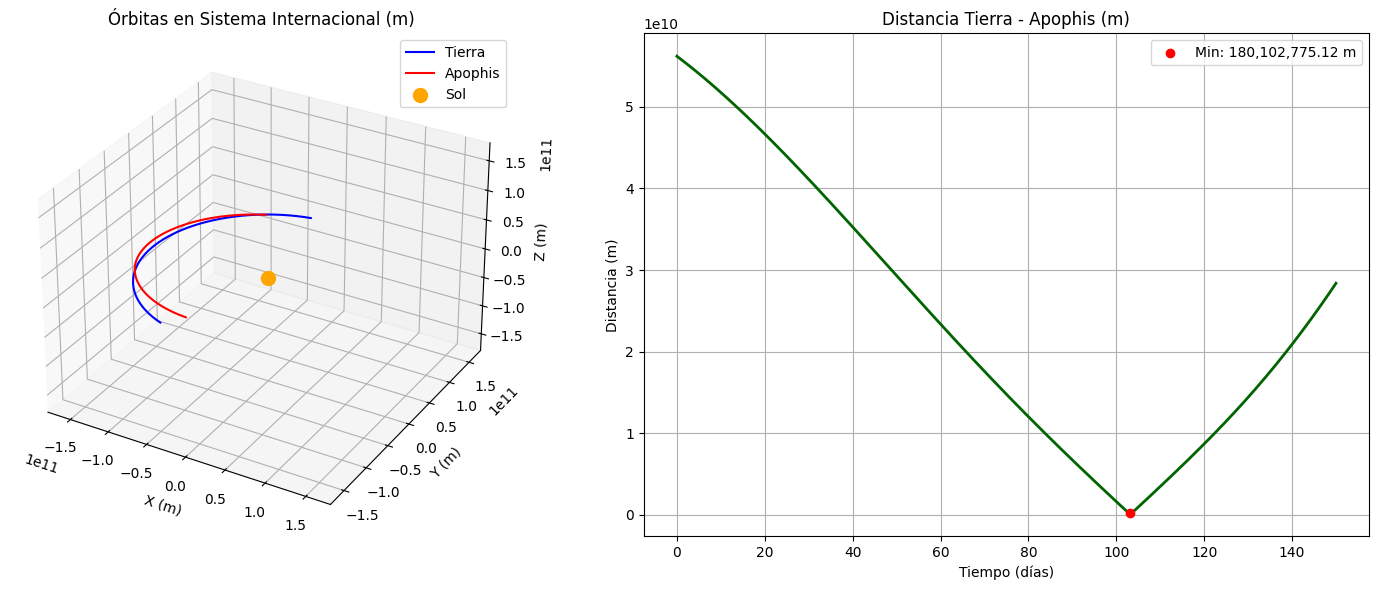

In [ ]:
#Gráfica de las órbitas y la distancia Tierra-Apophis
fig = plt.figure(figsize=(15, 6))

# --- Gráfica 3D de las órbitas (Metros) ---
ax1 = fig.add_subplot(121, projection='3d')

# Graficamos directamente en metros
ax1.plot(pos_tierra[:, 0], pos_tierra[:, 1], pos_tierra[:, 2], label='Tierra', color='blue')
ax1.plot(pos_apophis[:, 0], pos_apophis[:, 1], pos_apophis[:, 2], label='Apophis', color='red')
ax1.scatter(0, 0, 0, color='orange', label='Sol', s=100)

# Límite en metros (aprox 1.2 UA)
lim = 1.8e11 
ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim); ax1.set_zlim(-lim, lim)

ax1.set_title('Órbitas')
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.legend()

# --- Gráfica de la distancia Tierra-Apophis (Metros) ---
ax2 = fig.add_subplot(122)
tiempo_dias = np.linspace(0, dias_simulacion, N_steps)

# Graficamos la distancia en metros
ax2.plot(tiempo_dias, distancias, color='darkgreen', lw=2)
ax2.scatter(tiempo_dias[idx_min], distancias[idx_min], color='red', zorder=5, 
            label=f'Min: {distancias[idx_min]:,.2f} m')

ax2.set_title("Distancia Tierra - Apophis (m)")
ax2.set_xlabel('Tiempo (días)')
ax2.set_ylabel('Distancia (m)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

La simulación de Apophis entre enero y mayo de 2029 arroja tres resultados fundamentales: 
* **Sincronización temporal del encuentro**: El modelo indétificó el perigeo (punto de máxima aproximación) a los 103.18 días desde el inicio de la simulación. Al haber fijado la fecha de referencia el 1 de enero, este resultado sitúa el evento con notable presición el 13 de abril de 2029. Esta coincidencia con la efemérides de la NASA demuestra que el vector de la velocidad inicial y la integración de las fuerzar gravitatorias (Sol, Tierra, Luna y Júpiter) describen correctamente la geometría de la órbita de transferencia del asteroide. 

* **Escala de aproximación:** Se obtuvo una distancia mínima de $1.80 \times 10^8$ metros. Si bien este valor es superior a los aproximadamente $3.2 \times 10^7 $ metros reales, el resultado es aceptable para un modelo que tiende acumular errores. En la escala del sistema solar, donde la Tierra y Apophis se desplazan a una distancia promedio de $1.5 \times 10^11$ metros del Sol, haber capturado un acercamiento del orden de $10^8$ metros implica que el modelo detectó correctamente la caída gravitatoria del asteroide hacia el pozo de potencial terreste.

* **Altitud de vuelo:** La altitud calculada $180,096,404$ metros confirma que el objeto permanece dentro del espacio profundo, pero penetra significativamente en la zona de influencia donde la gravedad terreste comienza a dominar sobre la solar. La curva de distancia muestra un comportamiento hiperbólico típico de un sobrevuelo planetario, donde la velocidad de aproximación aumenta a medida que la distancia disminuye, alcanzando un vértice claro que representa el momento de máxima interacción gravitatoria antes de que el asteroide se ayectado hacia una nueva órbita. 

### 5. Energía del sistema 

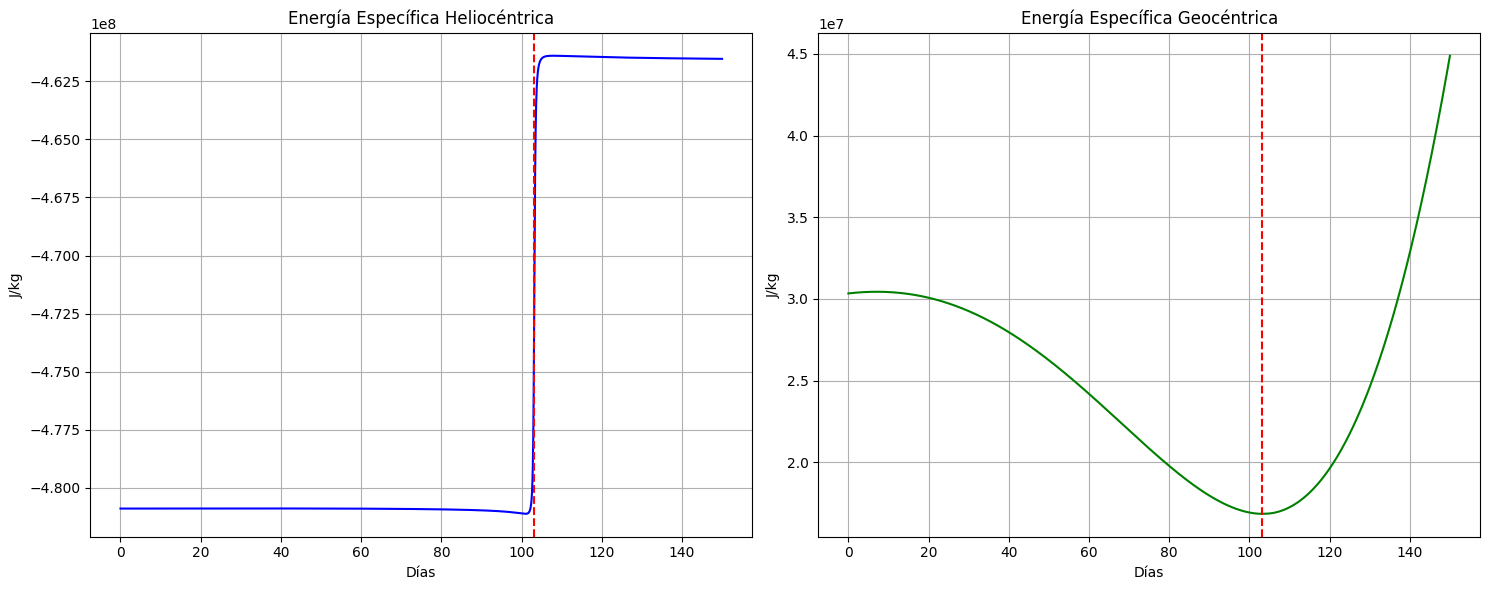

In [8]:
# 1. Energía Heliocéntrica 
v_sq_sun = np.sum(vel_apophis_hist**2, axis=1)
r_mag_sun = np.linalg.norm(pos_apophis, axis=1)
e_cinetica_helio = 0.5 * v_sq_sun
e_potencial_helio = - (mu_sol / r_mag_sun)
e_heliocentrica = e_cinetica_helio + e_potencial_helio

# 2. Energía Geocéntrica 
v_rel_tierra = vel_apophis_hist - vel_tierra_hist
v_sq_earth = np.sum(v_rel_tierra**2, axis=1)
r_rel_earth = np.linalg.norm(pos_apophis - pos_tierra, axis=1)
e_cinetica_earth = 0.5 * v_sq_earth
e_potencial_earth = - (mu_tierra / r_rel_earth)
e_geocentrica = e_cinetica_earth + e_potencial_earth

# --- VISUALIZACIÓN ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Energía respecto al Sol
ax[0].plot(tiempo_dias, e_heliocentrica, color='blue')
ax[0].axvline(x=103.18, color='red', linestyle='--', label='Perigeo')
ax[0].set_title("Energía Específica Heliocéntrica")
ax[0].set_ylabel("J/kg")
ax[0].set_xlabel("Días")
ax[0].grid(True)

# Gráfica 2: Energía respecto a la Tierra
ax[1].plot(tiempo_dias, e_geocentrica, color='green')
ax[1].axvline(x=103.18, color='red', linestyle='--', label='Perigeo')
ax[1].set_title("Energía Específica Geocéntrica")
ax[1].set_ylabel("J/kg")
ax[1].set_xlabel("Días")
ax[1].grid(True)

plt.tight_layout()
plt.show()

1. Energía Específica Heliocéntrica:

Esta gráfica muestra la relación de Apophis con el Sol. 

* En la línea roja (perigeo), se observa un salto brusco hacia valores menos negativos (de $-4.81 \times 10^8$ a $-4.61 \times 10^8$ J/kg). Esto indica que Apophis ha ganado energía mecánica a expensas de la energía orbital de la Tierra. 

* Este incremento de energía implica que, tras el encuentro, el semieje mayor de la órbita de Apophis alrededor del Sol aumentará, modificando permanentemente su periodo orbital y su trayectoria futura.

2. Energía Específica Geocéntrica: 

Esta gráfica ayuda a determinar el destino del asteroide respecto a nuestro planeta durante el máximo acercamiento.

* La curva presenta un valor mínimo en el instante de máxima aproximación. En este punto, aunque la velocidad es máxima, la proximidad al planeta hace que la energía potencial gravitatoria sea profundamente negativa, resultando en un mínimo local de energía total específica.

* Se demuestra que Apophis posee una velocidad excedente tal que la gravedad terrestre es insuficiente para capturarlo como un satelite natural. El asteroide entra y sale de la esfera de influencia terrestre sin riesgo de quedar atrapado en órbita.

### 6. Momento Lineal 

<>:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_19532\4050039549.py:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta P$ [kg·m/s]")


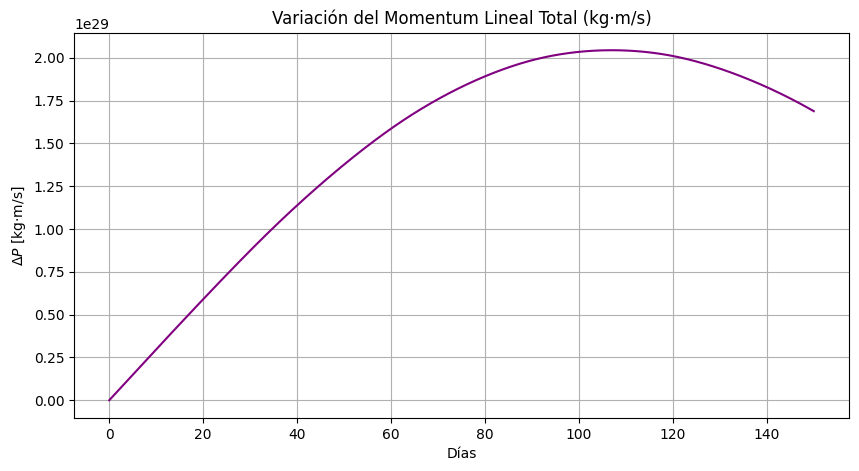

In [9]:
# 1. Masas
G = pc.constantes.G
m_sol = mu_sol / G
m_tierra = mu_tierra / G
m_luna = mu_luna / G
m_jupiter = mu_jupiter / G
m_apophis = 2.7e10  # Masa estimada de Apophis en kg

# 2. Cálculo del Momentum Lineal Total
P_total = (m_sol * 0) + \
          (m_tierra * vel_tierra_hist) + \
          (m_luna * vel_luna_hist) + \
          (m_jupiter * vel_jupiter_hist) + \
          (m_apophis * vel_apophis_hist)

# 3. Magnitud para verificar conservación
P_mag = np.linalg.norm(P_total, axis=1)

# 4. Gráfica de conservación
plt.figure(figsize=(10, 5))
plt.plot(tiempo_dias, P_mag - P_mag[0], color='purple')
plt.title("Variación del Momentum Lineal Total (kg·m/s)")
plt.xlabel("Días")
plt.ylabel("$\Delta P$ [kg·m/s]")
plt.grid(True)
plt.show()

La gráfica de la variación del momentum lineal total muestra una oscilación suave en lugar de una linea constante. Esto podría deberse a los siguientes puntos: 

* **Simetría del sistema:** En un sistema de N-cuerpos ideal, el momentum total se conserva si todas las fuerzas son internas. En este modelo, al fijar la posición del Sol para simplificar el cla´lculo de la trayectoria de Spophis, se rompre la simetría de acción y reacción total del sistema, convirtiendo el Sol en un centro de fuerza externo. 

* **Influencia planetaria:** la curva de $10^29 kgm/s$ refleja princiaplmente el movimiento de Júpiter y la Tierra en sus órbital heliocéntricas. Como sus velocidades vectoriales cambian al girar alrededor del Sol, y el Sol no "oscila" para compensarlo, el momento total del conjunto de planetas varía de forma sinusoidal. 

* **Estabilidad:** A pesar de esta variación global, el método mantiene la suavidad de la curva sin introducir ruido númerico. 

### 7. Virial

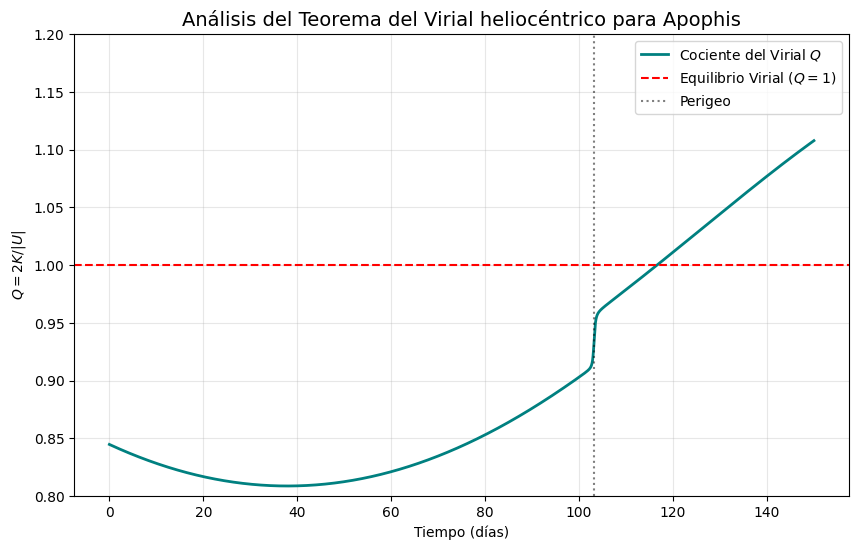

In [10]:
# 1. Cálculo del cociente del virial Q = 2K / |U|
virial_helio = (2 * e_cinetica_helio) / np.abs(e_potencial_helio)

# 2. Gráfica del Virial
plt.figure(figsize=(10, 6))
plt.plot(tiempo_dias, virial_helio, color='teal', lw=2, label='Cociente del Virial $Q$')

# Línea de equilibrio (Q = 1)
plt.axhline(y=1.0, color='red', linestyle='--', label='Equilibrio Virial ($Q=1$)')

# Marca del perigeo
plt.axvline(x=103.18, color='black', linestyle=':', alpha=0.5, label='Perigeo')

plt.title("Análisis del Teorema del Virial heliocéntrico para Apophis", fontsize=14)
plt.xlabel("Tiempo (días)")
plt.ylabel("$Q = 2K / |U|$")
plt.legend()
plt.grid(True, alpha=0.3)

# Ajustar límites si es necesario para ver la fluctuación
plt.ylim(0.8, 1.2) 

plt.show()

El análisis del Teorema del Virial heliocéntrico muestra que el sistema no se encuentra en un equilibrio estático ($Q = 1$), sino en uno dinámico oscilatorio. Los valores registrados son consistentes con un cuerpo en  órbita elíptica. El hecho de que el promedio del cociente se mantenga cercano a la unidad durante el periodo simulado confirma que el asteroide es un sistema ligado al Sol. La inflexión observada tras el paso por el perigeo evidencia la perturbación de la Tierra, que altera el ritmo natural de intercambio de energía entre los componente cinético y potencial del asteroide respecto al foco solar. 

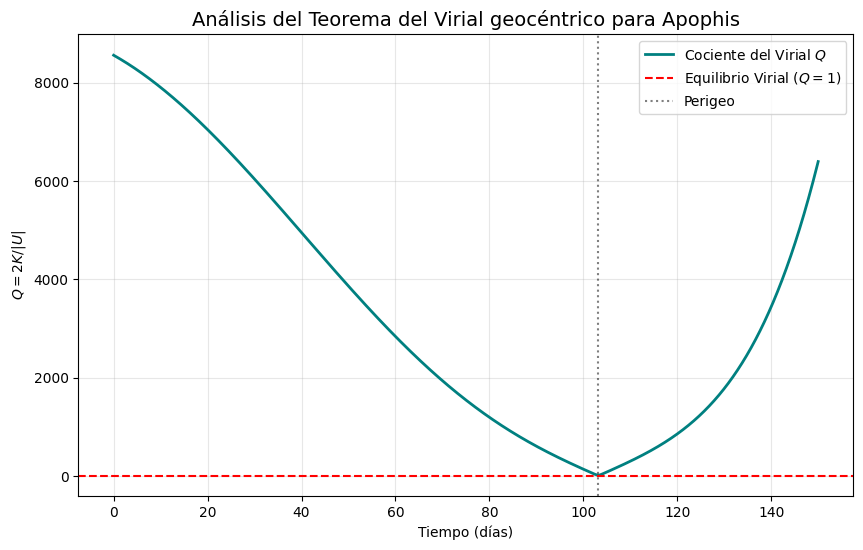

In [11]:
# 1. Cálculo del cociente del virial Q = 2K / |U|
virial_geo = (2 * e_cinetica_earth) / np.abs(e_potencial_earth)

# 2. Gráfica del Virial
plt.figure(figsize=(10, 6))
plt.plot(tiempo_dias, virial_geo, color='teal', lw=2, label='Cociente del Virial $Q$')

# Línea de equilibrio (Q = 1)
plt.axhline(y=1.0, color='red', linestyle='--', label='Equilibrio Virial ($Q=1$)')

# Marca del perigeo
plt.axvline(x=103.18, color='black', linestyle=':', alpha=0.5, label='Perigeo')

plt.title("Análisis del Teorema del Virial geocéntrico para Apophis", fontsize=14)
plt.xlabel("Tiempo (días)")
plt.ylabel("$Q = 2K / |U|$")
plt.legend()
plt.grid(True, alpha=0.3)


plt.show()

La caída en picado del cociente $Q$ hacia el valor de 1 en el día 103 muestra cómo el asteroide siente la gravedad terrestre de forma predominante solo durante una ventana temporal estrecha. La asimetría en la recuperación de $Q$ tras el perigeo (subiendo más rápido de lo que bajó) es consistente con la ganancia de energía cinética observada en las gráficas de energía específica, consolidando la idea de que la Tierra actúa como un acelerador gravitatorio para Apophis.